## Introduction<a id='introduction'></a>

**Purpose:**

Explore additional bivariates especially shot vs next shot. For any given shot, what is the outcome of that shot, what is the opponent likely to hit, and what is the eventual outcome of the rally? \
Explore visualization.

**Context:**

&emsp; Pickleball is an addictively fun racquet sport combining aspects of tennis, table tennis, and badminton and pickleball players are similarly diverse with players of all ages and all sports backgrounds. Players often spend hours on the courts both playing and socializing between games. A common topic of discussion amongst players is strategy with questions such as

* "Should I be dropping or driving my third shots?"
* "What kind of shots are more common at higher levels of play?"

This project aims to answer common questions in pickleball using data from pklmart.

**Data:**

Collection of pklmart data on Kaggle (https://www.kaggle.com/datasets/cakesofspan/pklmarts-competitive-pickleball-extracts). \
Pklmart (https://pklmart.com/)

**Outcomes from this notebook (EDA):**

**Outcomes from previous notebook (data wrangling):**

1. Data collected into one primary dataframe and saved as shot_rally.csv
    * shot_rally is larely clean with nan values in player_id, next_loc_x, next_loc_y but nan values there are inconsequential
2. Plotted univariate and bivariate distributions from game, rally, and shot dataframes. See outcomes from data wrangling notebook for detailed information.


## To-Do:

1. Check rally_outcome, see if makes sense
    * corrected rally_outcome. saved over previous shot_rally.csv and corrected data wrangling notebook
    * shot_rally now contains complete rallies only (complete meaning rally_len matches the number of shots observed)
2. Merge shot_rally with itself to connect shot with next shot (likely will do a for loop since multiple rallies are contained in shot_rally)
    * Done. See get_ngram_shot_type function
3. Explore how immediate shot choice affects the game by exploring what was the outcome of the shot, what shots the opponents made, and what was the rally outcome
    * calculated adjacency matrix for current shot vs next shot (meaning opponents next shot) and current shot vs next 2-shot (next next shot, meaning my next shot)
    * need to combine this with shot outcome and rally outcome to see impact
4. Fit rally_len distribution to a probability distribution, possibly Poisson. If fits to a Poisson distribution, extract lambda value

## Contents<a id='contents'></a>
* [Introduction](#introduction)
* [Contents](#contents)
* [Objectives](#objectives)
* [Exploring Data](#exploring_data)

<!-- * [Summary](#summary)     -->

## Objectives <a id='objectives'></a>

1. Explore additional bivariates especially shot vs next shot
2. Explore how we can use data to develop a model
    * possible ideas are a shot recommender
    * game simulator playing more aggressive/defensive shots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Andy's path to project data folder
data_path = '/content/drive/MyDrive/Colab Notebooks/DSCI 521 Final Project (Pickleball Analytics)/data/'

plt.rcParams.update({'font.size': 16})

In [3]:
game_df = pd.read_csv(data_path+'raw/game.csv')
player_df = pd.read_csv(data_path+'raw/player.csv')
team_df = pd.read_csv(data_path+'raw/team.csv')
rally_df = pd.read_csv(data_path+'raw/rally.csv')
shot_df = pd.read_csv(data_path+'raw/shot.csv')

shot_type_ref = pd.read_csv(data_path+'raw/shot_type_ref.csv', index_col=0)

shot_rally_df = pd.read_csv(data_path+'shot_rally.csv', index_col=0)

## Exploring Data<a id='exploring_data'></a>

### Shot Rally<a id='shot_rally'></a>

In [ ]:
shot_rally_df = pd.read_csv(data_path+'shot_rally.csv', index_col=0)

In [ ]:
def get_ngram_shot_type(df: pd.DataFrame, n: int, col_name: str) -> pd.DataFrame:
    '''
    Calculates n-grams of shot types assuming df has a column titled 'shot_type
        and a column titled 'rally_id'
    Returns df with additional column, col_name, containing n-gram
    Inputs:
        df: dataframe containing 'shot_type'; pd.DataFrame
        n: integer for n-gram, for n=1 calculates next shot type; int
        col_name: name of column to hold n-grams; str
    Outpts:
        df: new dataframe contain n-grams; pd.DataFrame
    '''
    inds = df.index
    next_shot_type = []
    prev_rally_id = ''
    prev_shot_type = ''
    gram_counter = n

    # loop through each row in shot_rally_df using index
    for i, ind in enumerate(inds):
        cur_rally_id = df.loc[ind, 'rally_id']
        # if reach new rally,
        # set next_shot_type = nan and set prev_rally_id to cur_rally_id
        if cur_rally_id != prev_rally_id:
            next_shot_type.append(np.nan)
            prev_rally_id = cur_rally_id
            gram_counter = n-1
        # otherwise, continue to add nans until counter reaches 0
        elif gram_counter > 0:
            next_shot_type.append(np.nan)
            gram_counter -= 1
        # gram_counter reaches 0 and in previous rally,
        # then set next shot type to prev shot type
        else:
            next_shot_type.append(prev_shot_type)
        # update prev_shot_type
        if i >= n-1:
            prev_shot_type = shot_rally_df.loc[inds[i-(n-1)], 'shot_type']

    df[col_name] = next_shot_type

    return df

In [ ]:
shot_rally_df = get_ngram_shot_type(shot_rally_df, 1, 'next_shot_type')
shot_rally_df = get_ngram_shot_type(shot_rally_df, 2, 'next_2-shot_type')

In [ ]:
# saving after creating 1-gram and 2-gram shot type columns
shot_rally_df.to_csv(data_path+'shot_rally.csv', index=True)

In [ ]:
# now creating adjacency matrix
adjacency_groupby = shot_rally_df[['shot_type', 'next_shot_type', 'shot_nbr']].groupby(['shot_type', 'next_shot_type']).count()
adjacency_groupby = adjacency_groupby.rename(columns={'shot_nbr':'count'})

adjacency_matrix = adjacency_groupby.unstack()
adjacency_matrix.columns = adjacency_matrix.columns.droplevel(0)

# normalizing rows
row_sums = adjacency_matrix.sum(axis=1)
adjacency_matrix = adjacency_matrix.div(row_sums, axis=0)
adjacency_matrix = adjacency_matrix.fillna(0)

In [ ]:
# and creating adjacency matrix for 2-shot gram
adjacency_groupby = shot_rally_df[['shot_type', 'next_2-shot_type', 'shot_nbr']].groupby(['shot_type', 'next_2-shot_type']).count()
adjacency_groupby = adjacency_groupby.rename(columns={'shot_nbr':'count'})

adjacency_2shot_matrix = adjacency_groupby.unstack()
adjacency_2shot_matrix.columns = adjacency_2shot_matrix.columns.droplevel(0)

# normalizing rows
row_sums = adjacency_2shot_matrix.sum(axis=1)
adjacency_2shot_matrix = adjacency_2shot_matrix.div(row_sums, axis=0)
adjacency_2shot_matrix = adjacency_2shot_matrix.fillna(0)

In [ ]:
pd.set_option('display.float_format', '{:,.3f}'.format)
adjacency_matrix

next_shot_type,A,D,E,HB,L,O,R,Res,SP,U,ball,tsDrp,tsDrv,tsLob,tzApp,tzRep
shot_type,,,,,,,,,,,,,,,,
A,0.000,0.000,0.000,0.738,0.016,0.000,0.000,0.115,0.049,0.033,0.000,0.000,0.000,0.000,0.049,0.000
D,0.002,0.761,0.002,0.065,0.010,0.000,0.000,0.002,0.128,0.008,0.000,0.000,0.000,0.000,0.009,0.014
E,0.017,0.026,0.000,0.534,0.009,0.000,0.000,0.060,0.060,0.000,0.000,0.000,0.000,0.000,0.276,0.017
HB,0.001,0.004,0.001,0.541,0.011,0.000,0.000,0.036,0.059,0.025,0.000,0.000,0.000,0.000,0.164,0.160
L,0.000,0.008,0.000,0.264,0.033,0.000,0.000,0.053,0.036,0.005,0.000,0.000,0.000,0.000,0.356,0.244
O,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
R,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.549,0.434,0.016,0.000,0.000
Res,0.000,0.064,0.004,0.613,0.009,0.000,0.000,0.055,0.086,0.012,0.000,0.000,0.000,0.000,0.110,0.046
SE,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [ ]:
adjacency_2shot_matrix

next_2-shot_type,A,D,E,HB,L,O,Res,SP,U,ball,tsDrp,tsDrv,tsLob,tzApp,tzRep
shot_type,,,,,,,,,,,,,,,
A,0.000,0.027,0.000,0.324,0.000,0.000,0.027,0.378,0.000,0.000,0.000,0.000,0.000,0.162,0.081
D,0.002,0.655,0.001,0.164,0.009,0.000,0.004,0.115,0.011,0.000,0.000,0.000,0.000,0.022,0.016
E,0.000,0.022,0.000,0.418,0.011,0.000,0.055,0.176,0.011,0.000,0.000,0.000,0.000,0.066,0.242
HB,0.000,0.121,0.002,0.440,0.006,0.000,0.023,0.070,0.029,0.000,0.000,0.000,0.000,0.091,0.219
L,0.000,0.031,0.000,0.211,0.134,0.000,0.065,0.017,0.018,0.000,0.000,0.000,0.000,0.372,0.152
R,0.000,0.202,0.001,0.167,0.001,0.000,0.003,0.032,0.025,0.000,0.000,0.000,0.000,0.045,0.524
Res,0.001,0.210,0.001,0.274,0.009,0.000,0.129,0.100,0.013,0.000,0.000,0.000,0.000,0.128,0.134
SE,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.549,0.434,0.016,0.000,0.000
SP,0.000,0.103,0.001,0.468,0.002,0.000,0.022,0.095,0.030,0.000,0.000,0.000,0.000,0.046,0.233


Text(0, 0.5, 'Percent')

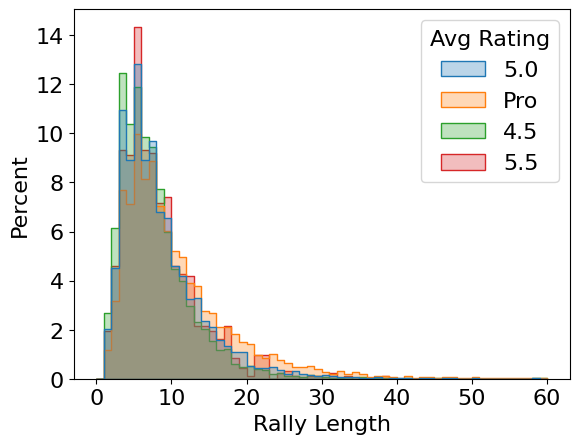

In [10]:
# Rally length by dupr rating
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
mask = [(x in ['4.5', '5.0', '5.5', 'Pro']) for x in my_df['skill_lvl']]

ax = sns.histplot(data=my_df[mask], x='rally_len', hue='skill_lvl', stat='percent',
             bins = np.arange(0, 61, 1), alpha=0.3, common_norm=False,
             label='Avg Rating', element='step')

ax.get_legend().set_title('Avg Rating')
plt.xlabel('Rally Length')
plt.ylabel('Percent')

In [ ]:
from scipy.optimize import curve_fit
from scipy.special import factorial
from scipy.stats import poisson, lognorm, binom, geom

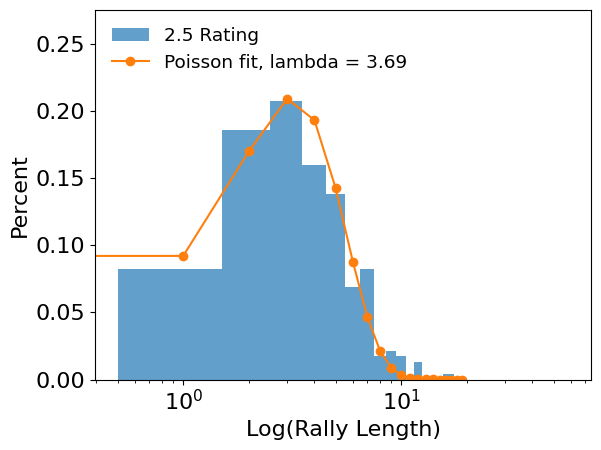

In [ ]:
data = my_df[my_df['skill_lvl']=='2.5']['rally_len']

# the bins should be of integer width, because poisson is an integer distribution
bins = np.arange(60) - 0.5
entries, bin_edges, patches = plt.hist(data, bins=bins, density=True,
                                       label='2.5 Rating', alpha=0.7)

# calculate bin centers
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])


def fit_function(k, lamb):
    '''poisson function, parameter lamb is the fit parameter'''
    return poisson.pmf(k, lamb)


# fit with curve_fit
parameters, cov_matrix = curve_fit(fit_function, bin_centers, entries)

# plot poisson-deviation with fitted parameter
x_plot = np.arange(0, 20)

plt.plot(
    x_plot,
    fit_function(x_plot, *parameters),
    marker='o', linestyle='-',
    label=f'Poisson fit, lambda = {parameters[0]:.2f}',
)
plt.xlabel('Log(Rally Length)')
plt.ylabel('Percent')
plt.xscale('log')
plt.ylim([0,0.275])
plt.legend(frameon=False, fontsize='small', loc=2)
plt.show()

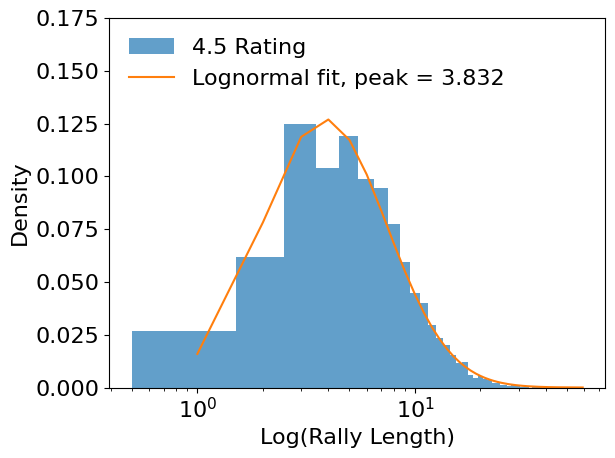

In [ ]:
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
my_df = my_df[my_df['rally_len'] > 0]
data = my_df[my_df['skill_lvl']=='4.5']['rally_len']

# 2. Fit the data to a lognormal distribution
# The 'fit' function returns the estimated shape, loc, and scale parameters.
# It is recommended to set floc=0 to fix the location parameter to zero.
shape_est, loc_est, scale_est = lognorm.fit(data, floc=0)

# 3. Interpret the estimated parameters
# The est mean (mu) of the *underlying* normal distribution can be derived:
mu_est = np.log(scale_est)
# The est standard deviation (sigma) of the *underlying* normal distribution
sigma_est = shape_est

# 4. Visualize the fit
data_sorted = np.sort(data)
pdf_fitted = lognorm.pdf(data_sorted, shape_est, loc_est, scale_est)

plt.hist(data, bins=np.arange(60) - 0.5, density=True, alpha=0.7,
         label='4.5 Rating')
plt.plot(data_sorted, pdf_fitted, marker='', linestyle='-',
         label=f'Lognormal fit, peak = {np.exp(mu_est-sigma_est**2):.3f}')
plt.xlabel('Log(Rally Length)')
plt.ylim([0,0.175])
plt.ylabel('Density')
plt.xscale('log')
plt.legend(frameon=False, loc=2)
plt.show()

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def weibull(x, lam, k):
    '''Weibull distribution'''
    return (k/lam)*(x/lam)**(k-1)*np.exp(-(x/lam)**k)

def poisson(x, lam):
    return lam**x * (np.exp(-lam)) / factorial(x)

def plot_fit_rally_len(fit_function, skill_lvl):
    # create df of rally_len for given skill_lvl
    my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
    my_df = my_df[my_df['rally_len'] > 0]
    data = my_df[my_df['skill_lvl']==skill_lvl][['rally_len', 'rally_id']]
    data_counts = data.groupby('rally_len').count()

    total_observations = data_counts.sum().values[0]
    # Convert counts to probabilities for fitting
    x = np.array(data_counts.index)
    y = data_counts['rally_id'].values/total_observations

    # plot histogram of rally_len
    bins = np.arange(60) - 0.5
    _, _, _ = plt.hist(data['rally_len'], bins=bins, density=True,
                                        label=skill_lvl+' Rating', alpha=0.7)

    # fit with curve_fit
    parameters, cov_matrix = curve_fit(fit_function, x, y)

    # plot weibull with fitted parameter
    yhat = fit_function(x, *parameters)

    print(rmse(y, yhat))
    print(*parameters)
    plt.plot(
        x,
        fit_function(x, *parameters),
        marker='o', linestyle='-',
        label='Function fit',
    )
    plt.xlabel('Log(Rally Length)')
    plt.ylabel('Percent')
    plt.xscale('log')
    plt.ylim([0,0.275])
    plt.legend(frameon=False, fontsize='small', loc=2)
    plt.show()

    return

In [ ]:
def fit_rally_len_weibull(skill_lvl):
    '''
    Fits distribution of rally_len for given skill_lvl to a Weibull distribution
    Returns x, y, yhat, parameters, error
    '''
    # create df of rally_len for given skill_lvl
    my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
    my_df = my_df[my_df['rally_len'] > 0]
    data = my_df[my_df['skill_lvl']==skill_lvl][['rally_len', 'rally_id']]
    data_counts = data.groupby('rally_len').count()

    total_observations = data_counts.sum().values[0]
    # Convert counts to probabilities for fitting
    x = np.array(data_counts.index)
    y = data_counts['rally_id'].values/total_observations

    # fit with curve_fit
    parameters, cov_matrix = curve_fit(weibull, x, y)

    # plot weibull with fitted parameter
    yhat = weibull(x, *parameters)

    error = rmse(y, yhat)

    return x, y, yhat, parameters, error

def plot_rally_len_weibull(skill_lvls):
    fits = {}
    for x in skill_lvls:
        fits[x] = fit_rally_len_weibull(x)

    fig = plt.figure(figsize=(4, 4))

    for ind, val in enumerate(skill_lvls):
        x, y, yhat, parameters, error = fits[val]

        plt.plot(x, y, label=val+' Rating',
                 linewidth=1.5, color='C'+str(ind))
        plt.plot(
            x, yhat,
            linestyle='--', color='C'+str(ind),
            label=f'Fit (lambda, k) \n     ({parameters[0]:.2f}, {parameters[1]:.2f})',
        )

    plt.xlabel('Log(Rally Length)')
    plt.ylabel('Percent')
    plt.xscale('log')
    plt.ylim([0,0.15])
    plt.legend(frameon=False, fontsize='small',
               loc='right', bbox_to_anchor=(1.7, 0.5))
    return

/tmp/ipython-input-1858/2813995659.py:6: RuntimeWarning: invalid value encountered in power
  return (k/lam)*(x/lam)**(k-1)*np.exp(-(x/lam)**k)
/tmp/ipython-input-1858/2813995659.py:6: RuntimeWarning: invalid value encountered in power
  return (k/lam)*(x/lam)**(k-1)*np.exp(-(x/lam)**k)
/tmp/ipython-input-1858/2813995659.py:6: RuntimeWarning: invalid value encountered in power
  return (k/lam)*(x/lam)**(k-1)*np.exp(-(x/lam)**k)


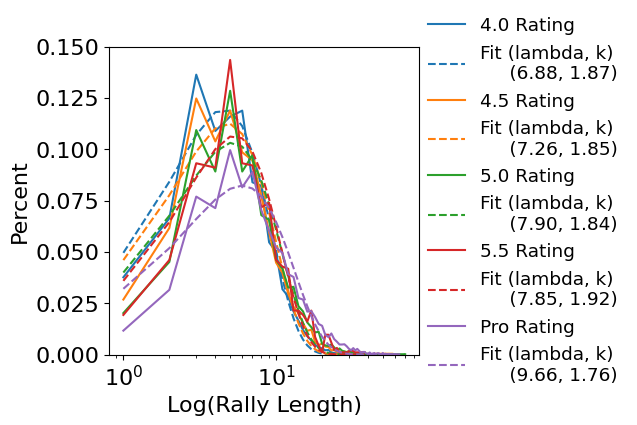

In [ ]:
plot_rally_len_weibull(['4.0', '4.5', '5.0', '5.5', 'Pro'])

In [ ]:
game_df.skill_lvl.value_counts()

,count
skill_lvl,
4.0,328
Pro,196
5.0,163
4.5,131
3.5,65
5.5,22
3.0,18
2.5,8
Senior Pro,4


In [ ]:
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id', how='left')

In [ ]:
mask = [True if x in ['4.5', '5.0', '5.5', 'Pro', 'Senior Pro'] else False for x in game_df['skill_lvl']]
my_df = game_df[['game_id', 'skill_lvl']][mask]
my_df = pd.merge(rally_df, my_df, on='game_id', how='left')

In [ ]:
my_df.shape

(40702, 25)

In [ ]:
mask = [True if x in ['3.5', '4.0'] else False for x in game_df['skill_lvl']]
my_df = game_df[['game_id', 'skill_lvl']][mask]
my_df = pd.merge(rally_df, my_df, on='game_id', how='left')

In [ ]:
my_df.shape

(40702, 25)

In [ ]:
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id', how='left')
mask = [True if x in ['3.5', '4.0'] else False for x in my_df['skill_lvl']]

In [ ]:
my_df[mask].shape

(17184, 25)

In [ ]:
shot_rally_df.iloc[:5,5:]

,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
289847,T135,T136,T135,S72059,4,HB,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
289846,T135,T136,T135,S72058,3,tsDrv,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN
289845,T135,T136,T135,S72057,2,R,P184,17.53,20.76,8.71,-20.58,Unforced Error,Extend Rally,Game Over,tsDrv,HB
289844,T135,T136,T135,S72056,1,SE,P181,7.42,-20.94,17.53,20.76,Unforced Error,Start Rally,Game Over,R,tsDrv
289843,T135,T136,T135,S72055,4,HB,P184,11.56,7.72,NaN,NaN,Unforced Error,Unforced Error,Point,NaN,NaN


In [ ]:
shot_rally_df.head(3)

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,...,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,...,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,...,P184,17.53,20.76,8.71,-20.58,Unforced Error,Extend Rally,Game Over,tsDrv,HB


In [ ]:
rally_df.head(2)

,rally_id,game_id,match_id,rally_nbr,w_team_id,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,...,ending_type,ending_player_id,srv_switch_ind,rtrn_switch_ind,srv_team_flipped_ind,rtrn_team_flipped_ind,srv_team_rs_player_id,srv_team_ls_player_id,rtrn_team_rs_player_id,rtrn_team_ls_player_id
0,R8968,G208,M113,6,T152,T152,P202,T155,P70,P202,...,Other,NaN,Y,N,N,N,P203,P202,P70,P205
1,R8963,G208,M113,1,T155,T152,P202,T155,P70,NaN,...,Error,P203,Y,N,N,N,P203,P202,P70,P205


In [ ]:
my_df = rally_df[['ts_type', 'ending_type', 'rally_id']]
my_df.groupby(['ts_type', 'ending_type']).count()

rally_id
ts_type ending_type             
Drive   Error               8547
        Other               1109
        Unforced Error      1555
        Winner              5447
Drop    Error               9791
        Other               1732
        Unforced Error      1644
        Winner              6984
Lob     Error                309
        Other                 21
        Unforced Error        33
        Winner               245

In [ ]:
shot_rally_df.shot_type.value_counts()

,count
shot_type,
D,59533
HB,45135
SE,39906
R,38764
tzRep,35076
tzApp,25989
tsDrp,20062
tsDrv,15873
SP,14233


In [ ]:
# across all skill levels
mask = [True if x in ['tsDrp', 'tsDrv'] else False for x in shot_rally_df.shot_type]
my_df = shot_rally_df[mask][['shot_type', 'rally_outcome', 'rally_id']]
data = my_df.groupby(['shot_type', 'rally_outcome']).count()
data

rally_id
shot_type rally_outcome          
tsDrp     Game Over           430
          Next Server        5246
          Point              7656
          Side Out           6730
tsDrv     Game Over           381
          Next Server        3858
          Point              6252
          Side Out           5382

In [ ]:
data.loc['tsDrp']/data.loc['tsDrp'].sum()*100

,rally_id
rally_outcome,
Game Over,2.143356
Next Server,26.148938
Point,38.161699
Side Out,33.546007


In [ ]:
data.loc['tsDrv']/data.loc['tsDrv'].sum()*100

,rally_id
rally_outcome,
Game Over,2.400302
Next Server,24.305424
Point,39.387639
Side Out,33.906634


In [ ]:
my_df = pd.merge(shot_rally_df, game_df[['game_id', 'skill_lvl']], on='game_id', how='left')
cond1 = [True if x in ['tsDrp', 'tsDrv'] else False for x in my_df.shot_type]
cond2 = [True if x in ['4.5', '5.0', '5.5', 'Pro', 'Senior Pro'] else False for x in my_df.skill_lvl]
mask = [(x1 and x2) for x1, x2 in zip(cond1, cond2)]
my_df = my_df[mask][['shot_type', 'rally_outcome', 'rally_id']]
data = my_df.groupby(['shot_type', 'rally_outcome']).count()
data

rally_id
shot_type rally_outcome          
tsDrp     Game Over           262
          Next Server        2989
          Point              4663
          Side Out           4130
tsDrv     Game Over           197
          Next Server        1846
          Point              3376
          Side Out           2881

In [ ]:
data.loc['tsDrp']

,rally_id
rally_outcome,
Game Over,262
Next Server,2989
Point,4663
Side Out,4130


In [ ]:
data.loc['tsDrv']

,rally_id
rally_outcome,
Game Over,197
Next Server,1846
Point,3376
Side Out,2881


In [25]:
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id', how='left')
mask = [True if x in ['5.5', 'Pro'] else False for x in my_df.skill_lvl]
my_df = my_df[mask]
mask = [True if x < 30 else False for x in my_df.rally_len]
my_df = my_df[mask]

In [26]:
my_df[['rally_id', 'game_id', 'skill_lvl', 'rally_len']]

,rally_id,game_id,skill_lvl,rally_len
35,R12704,G294,Pro,26.0
37,R12680,G294,Pro,12.0
38,R12679,G294,Pro,24.0
39,R12681,G294,Pro,2.0
40,R12682,G294,Pro,4.0
...,...,...,...,...
40135,R50756,G1196,5.5,4.0
40136,R50757,G1196,5.5,6.0
40137,R50758,G1196,5.5,4.0
40138,R50736,G1196,5.5,3.0
